![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

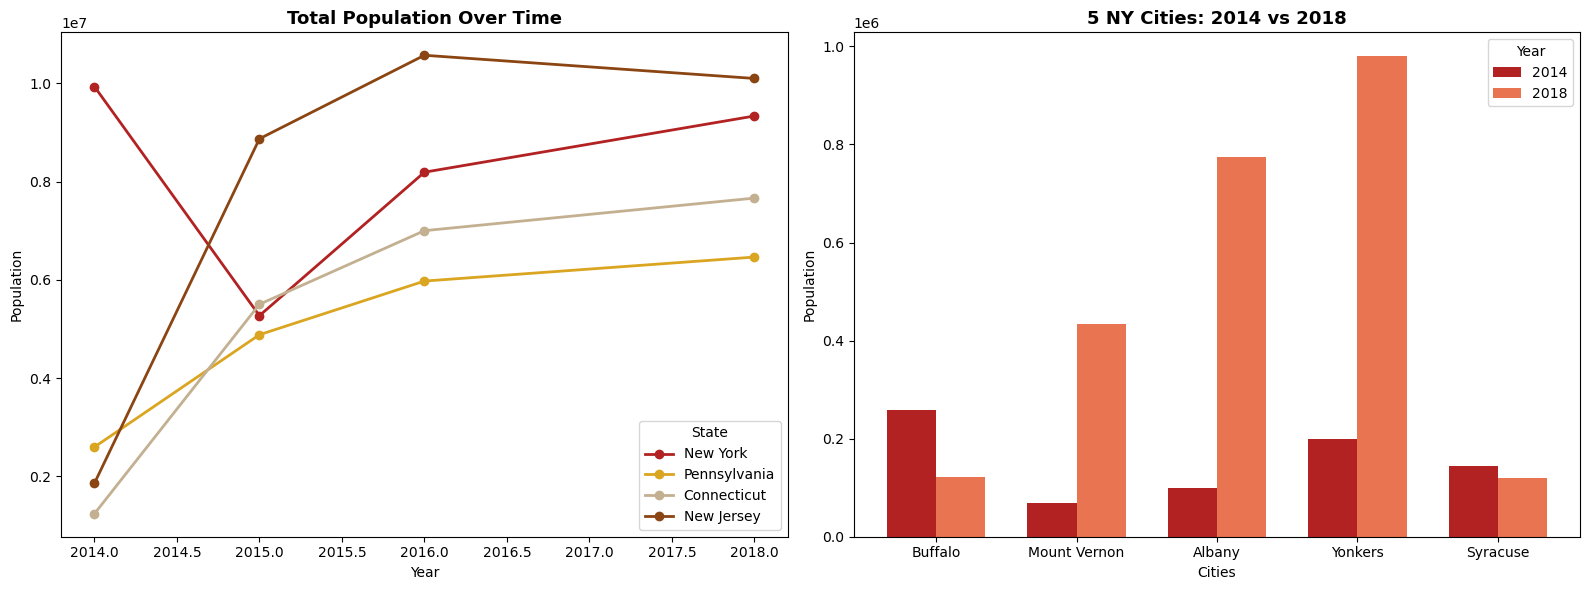

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Question 1 
df1 = pd.read_csv("us-cities-top-1k-multi-year.csv")
df1

states = ['New York', 'Pennsylvania', 'Connecticut', 'New Jersey']

df_filtered = df1[df1['State'].isin(states)]
df_grouped = df_filtered.groupby(['State', 'year'])['Population'].sum().reset_index()

colors = ['#b22222', 'goldenrod', '#c3b091', '#8b4513']


for state, color in zip(states, colors):
    one_state = df_grouped[df_grouped['State'] == state]   ## filter the df just for one country at a time in rows
    ax1.plot(one_state['year'], one_state['Population'],
             color=color, marker='o', linewidth=2, label=state)

ax1.set_title('Total Population Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population')
ax1.legend(title='State')



## Question 2
df_ny = df1[df1['State'] == 'New York']
# df_ny

cities = ['Mount Vernon', 'Buffalo', 'Albany', 'Yonkers', 'Syracuse']
df_ny5 = df_ny[df_ny['City'].isin(cities)]

df_2014 = df_ny5[df_ny5['year'] == 2014]
df_2018 = df_ny5[df_ny5['year'] == 2018]

x = np.arange(len(cities)) ### center of each city slot in the graph
width = 0.35

ax2.bar(x - width/2, df_2014['Population'], width=width, color='#b22222', label='2014')
ax2.bar(x + width/2, df_2018['Population'], width=width, color='#e97451',    label='2018')

ax2.set_title('5 NY Cities: 2014 vs 2018', fontsize=13, fontweight='bold')
ax2.set_xlabel('Cities')
ax2.set_ylabel('Population')
ax2.set_xticks(x)
ax2.set_xticklabels(df_2014['City'])
ax2.legend(title='Year')


plt.tight_layout()
plt.show()


## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [6]:
df2 = pd.read_csv("job-automation-probability.csv")
# df2

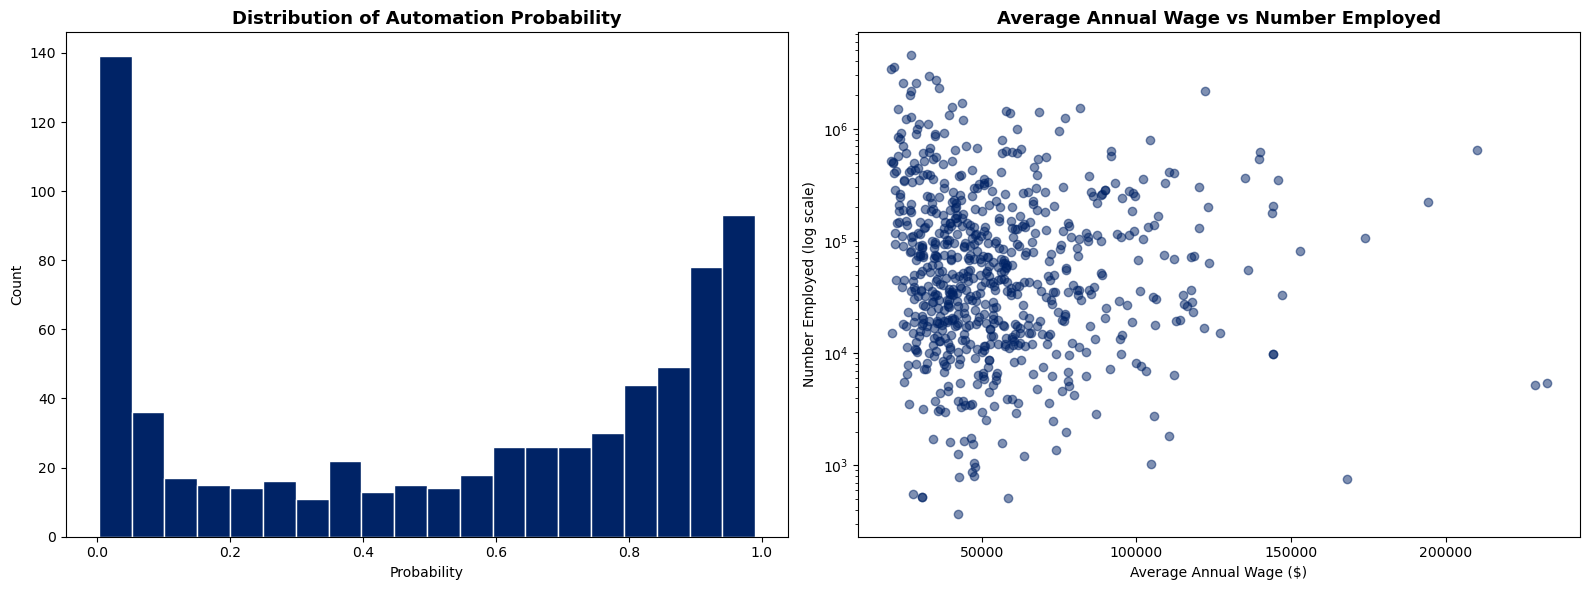

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## histogram
ax1.hist(df2['probability'],  bins=20,  color='#002366', edgecolor='white')         

ax1.set_title('Distribution of Automation Probability', fontsize=13, fontweight='bold')
ax1.set_xlabel('Probability')
ax1.set_ylabel('Count')

## scatter 
ax2.scatter(df2['average_ann_wage'],df2['numbEmployed'], color='#002366', alpha=0.5)

ax2.set_yscale('log')                  
ax2.set_title('Average Annual Wage vs Number Employed', fontsize=13, fontweight='bold')
ax2.set_xlabel('Average Annual Wage ($)')
ax2.set_ylabel('Number Employed (log scale)')

plt.tight_layout()
plt.savefig('job_automation_graphs.png', dpi=150, bbox_inches='tight')  

plt.show()